Credit Risk Analytics

1. Data Preprocessing,
2. Data Cleaning,
3. Data Standardization,
4. Feature Engineering,
5. EDA,
6. Strategy Building,
7. Model Building,
8. Hyperparameter Tuning,
9. Deep Neural Network building,
10. Model Evaluation

has been done.

Next up:
1. is Randomized Search for ANN with more hyperparameters - Different Optimizers, Learning Rate, Number of Neurons in hidden layers (by having same number of neurons for each hidden layer).
2. Building Dashboard in Tableau and doing some basic analysis using SQLite
3. Report Creation and pushing code to Github.
4. Adding project to DataSciencePortfolio Portfolio and General Portfolio.
5. Adding Code to Cloud.



In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv('/content/drive/MyDrive/PRO/Analytics - Projects/Credit Risk Analytics/credit_risk_dataset.csv')

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='person_home_ownership', ylabel='count'>

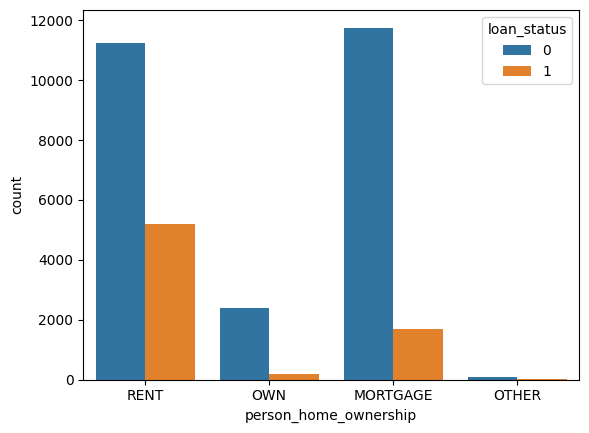

In [6]:
sns.countplot(x='person_home_ownership', hue='loan_status', data=df)

Person with home ownership as Mortgage and Own home tend to default less compared to the ones with ownership as Rent.

<Axes: ylabel='person_income'>

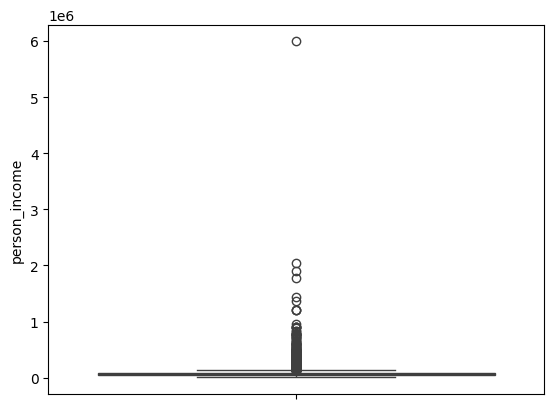

In [7]:
sns.boxplot(df['person_income'])

<Axes: xlabel='person_income', ylabel='Count'>

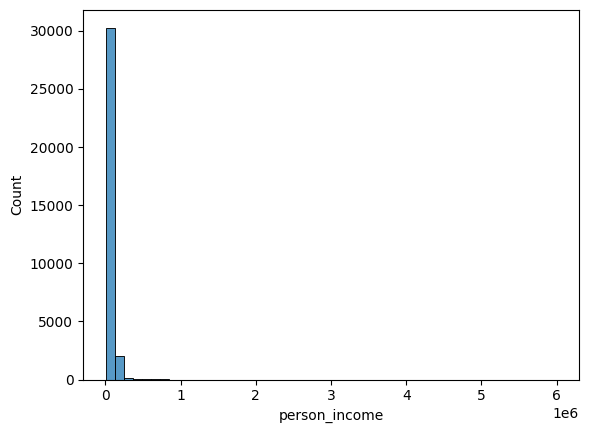

In [8]:
sns.histplot(df['person_income'], bins=50)

<Axes: >

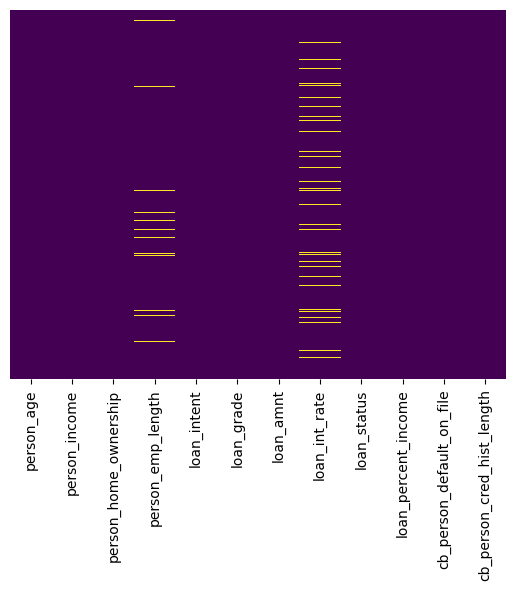

In [9]:

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [10]:
df.head(2)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2


person_emp_length =	Employment length (in years)

cb_person_default_on_file = historical Default

cb_person_cred_hist_length = credit history length

In [11]:
df['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

<Axes: xlabel='person_home_ownership', ylabel='person_emp_length'>

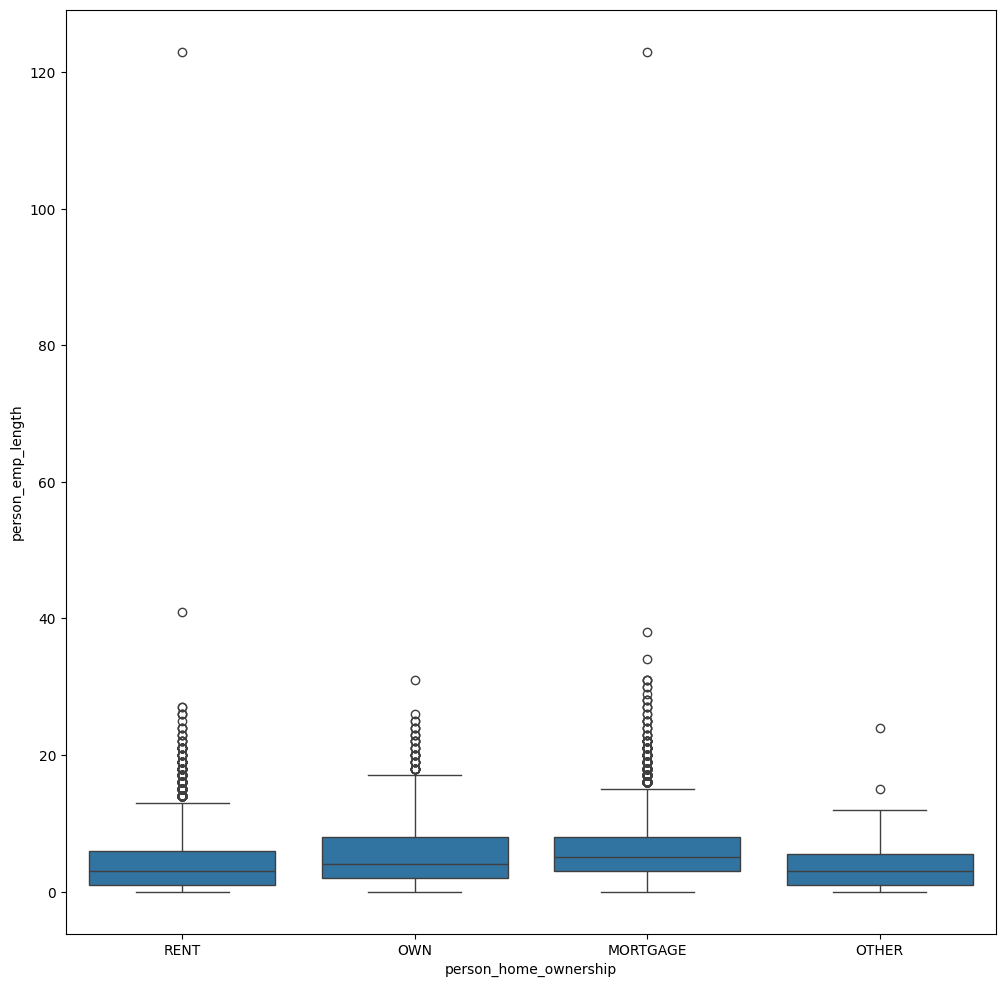

In [12]:
plt.figure(figsize=(12,12))
sns.boxplot(x='person_home_ownership', y='person_emp_length', data=df)

In [13]:
# plt.figure(figsize=(12,12))
# sns.boxplot(x='loan_intent', y='person_emp_length', data=df)

In [14]:
# df.head(2)

In [15]:
def impute_emp_length(cols):
  emp_length = cols[0]
  home_ownership = cols[1]
  if pd.isnull(emp_length):
    if home_ownership == 'MORTGAGE':
      return 24
    elif home_ownership == 'RENT':
      return 22
    elif home_ownership == 'OWN':
      return 23
    else:
      return 22
  else:
    return emp_length


In [16]:
df['person_emp_length'] = df[['person_emp_length','person_home_ownership']].apply(impute_emp_length,axis=1)

/tmp/ipykernel_362/2625158503.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  emp_length = cols[0]
/tmp/ipykernel_362/2625158503.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  home_ownership = cols[1]


<Axes: >

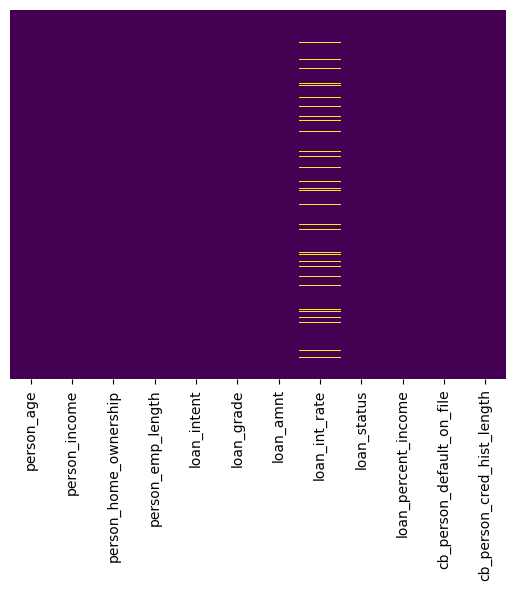

In [17]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


<Axes: xlabel='person_age', ylabel='person_emp_length'>

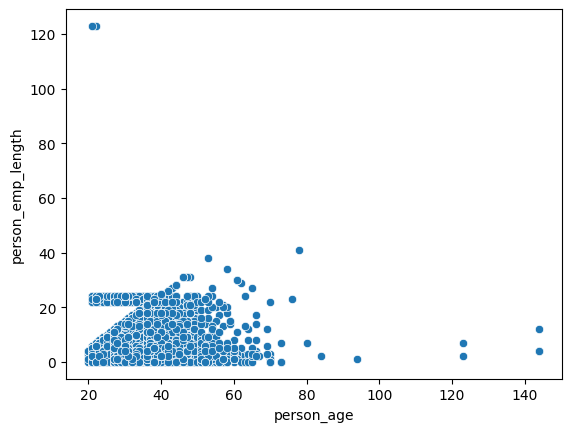

In [19]:
sns.scatterplot(x='person_age', y='person_emp_length',data=df)

<Axes: xlabel='loan_intent', ylabel='loan_int_rate'>

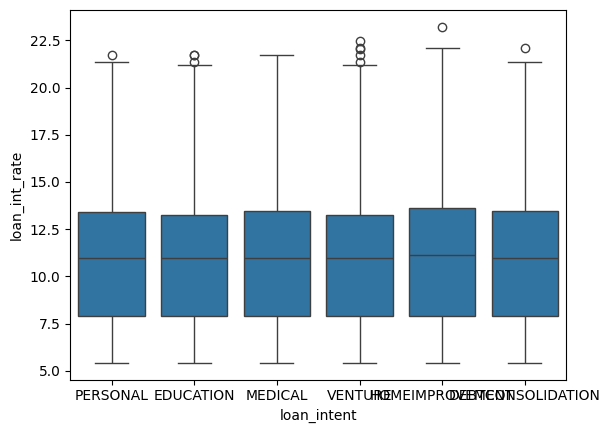

In [20]:
sns.boxplot(x='loan_intent', y='loan_int_rate', data=df)

In [21]:
df.head(1)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3


<Axes: xlabel='loan_grade', ylabel='loan_int_rate'>

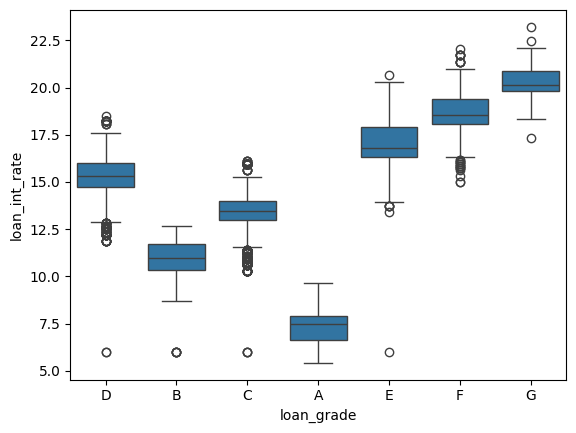

In [22]:
sns.boxplot(x='loan_grade', y='loan_int_rate', data=df)

In [23]:
print('A = ',df[df['loan_grade']=='A']['loan_int_rate'].mean())
print('B = ',df[df['loan_grade']=='B']['loan_int_rate'].mean())
print('C = ',df[df['loan_grade']=='C']['loan_int_rate'].mean())
print('D = ',df[df['loan_grade']=='D']['loan_int_rate'].mean())
print('E = ',df[df['loan_grade']=='E']['loan_int_rate'].mean())
print('F = ',df[df['loan_grade']=='F']['loan_int_rate'].mean())
print('G = ',df[df['loan_grade']=='G']['loan_int_rate'].mean())

A =  7.327650910579088
B =  10.99555508249069
C =  13.46354152367879
D =  15.361448400724202
E =  17.009455164585695
F =  18.609158878504672
G =  20.25152542372881


In [24]:
def impute_int(cols):
  int_rate = cols[0]
  grade = cols[1]
  if pd.isnull(int_rate):
    if grade == 'A':
      return 7.32
    elif grade == 'B':
      return 10.99
    elif grade == 'C':
      return 13.46
    elif grade == 'D':
      return 15.36
    elif grade == 'E':
      return 17.00
    elif grade == 'F':
      return 18.60
    elif grade == 'G':
      return 20.25
  else:
    return int_rate

In [25]:
df['loan_int_rate']= df[['loan_int_rate','loan_grade']].apply(impute_int, axis=1)

/tmp/ipykernel_362/1576650111.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  int_rate = cols[0]
/tmp/ipykernel_362/1576650111.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  grade = cols[1]


In [26]:
# sns.boxplot(x='person_home_ownership', y='loan_int_rate', data=df)

In [27]:
# print('RENT = ',df[df['person_home_ownership']=='RENT']['loan_int_rate'].mean())
# print('OWN = ',df[df['person_home_ownership']=='OWN']['loan_int_rate'].mean())
# print('MORTGAGE = ',df[df['person_home_ownership']=='MORTGAGE']['loan_int_rate'].mean())
# print('OTHER = ',df[df['person_home_ownership']=='OTHER']['loan_int_rate'].mean())

In [28]:
# def impute_int(cols):
#   int_rate = cols[0]
#   home_ownership = cols[1]
#   if pd.isnull(int_rate):
#     if home_ownership == 'MORTGAGE':
#       return 10.48
#     elif home_ownership == 'RENT':
#       return 11.45
#     elif home_ownership == 'OWN':
#       return 10.86
#     else:
#       return 12.03
#   else:
#     return int_rate

In [29]:
# df['loan_int_rate']= df[['loan_int_rate','person_home_ownership']].apply(impute_int, axis=1)

<Axes: >

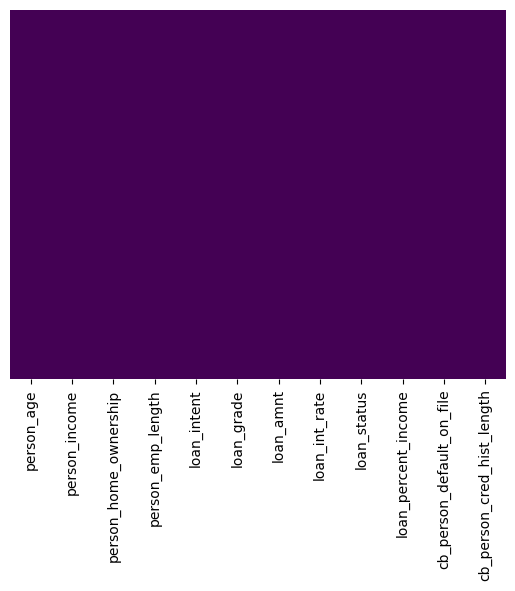

In [30]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [31]:
df.head(1)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3


<Axes: xlabel='loan_grade', ylabel='Count'>

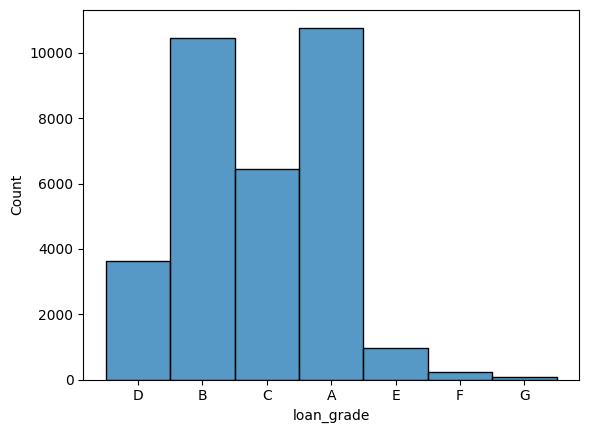

In [32]:
sns.histplot(df['loan_grade'])

/tmp/ipykernel_362/4075116053.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['loan_int_rate'], kde=False, hist_kws={'edgecolor':'black', 'linewidth':1})


<Axes: xlabel='loan_int_rate'>

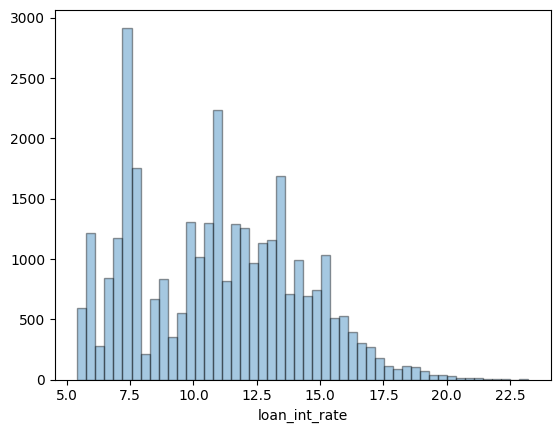

In [33]:
sns.distplot(df['loan_int_rate'], kde=False, hist_kws={'edgecolor':'black', 'linewidth':1})

<Axes: xlabel='loan_amnt', ylabel='Count'>

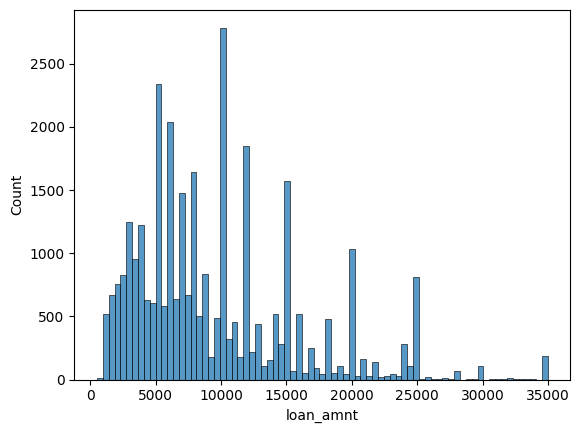

In [34]:
sns.histplot(df['loan_amnt'])

In [35]:
df.head(1)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3


In [36]:
df['cb_person_default_on_file'].unique()

array(['Y', 'N'], dtype=object)

In [37]:
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].apply(lambda x:1 if x=='Y' else 0)

In [38]:

df.head(2)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,1,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,0,2


In [39]:
ndf= df[['person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'loan_status',
    'cb_person_default_on_file',
    'cb_person_cred_hist_length']]

<Axes: >

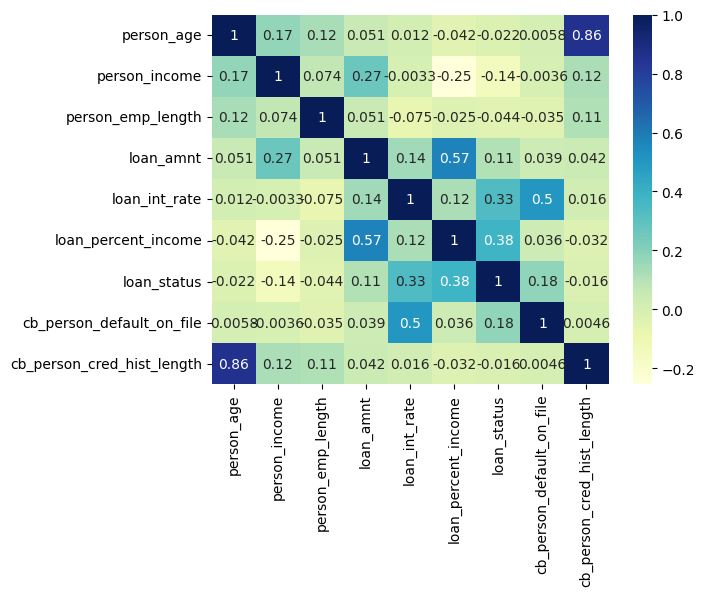

In [40]:
sns.heatmap(ndf.corr(), cmap='YlGnBu', annot=True)

In [41]:
df.head(1)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,1,3


<Axes: xlabel='loan_amnt', ylabel='person_income'>

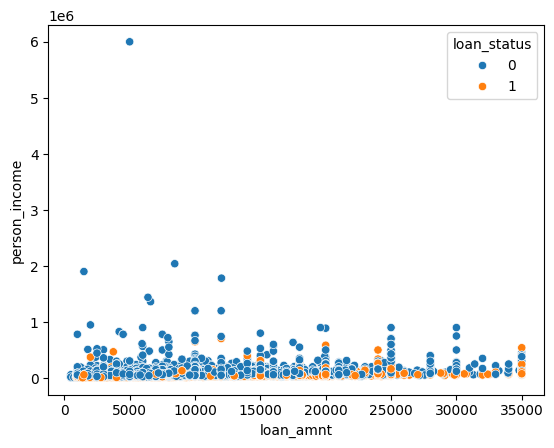

In [42]:
sns.scatterplot(x='loan_amnt', y='person_income', data=df, hue='loan_status')

Loan status when 0 implies Non Defaulter otherwise Defaulter.

From above chart it can be said, defaulters are more tilted towards the side of high loan amount compared to low loan amount.

Also people with extremely high income can be said to be Non Defaulters based on the data.

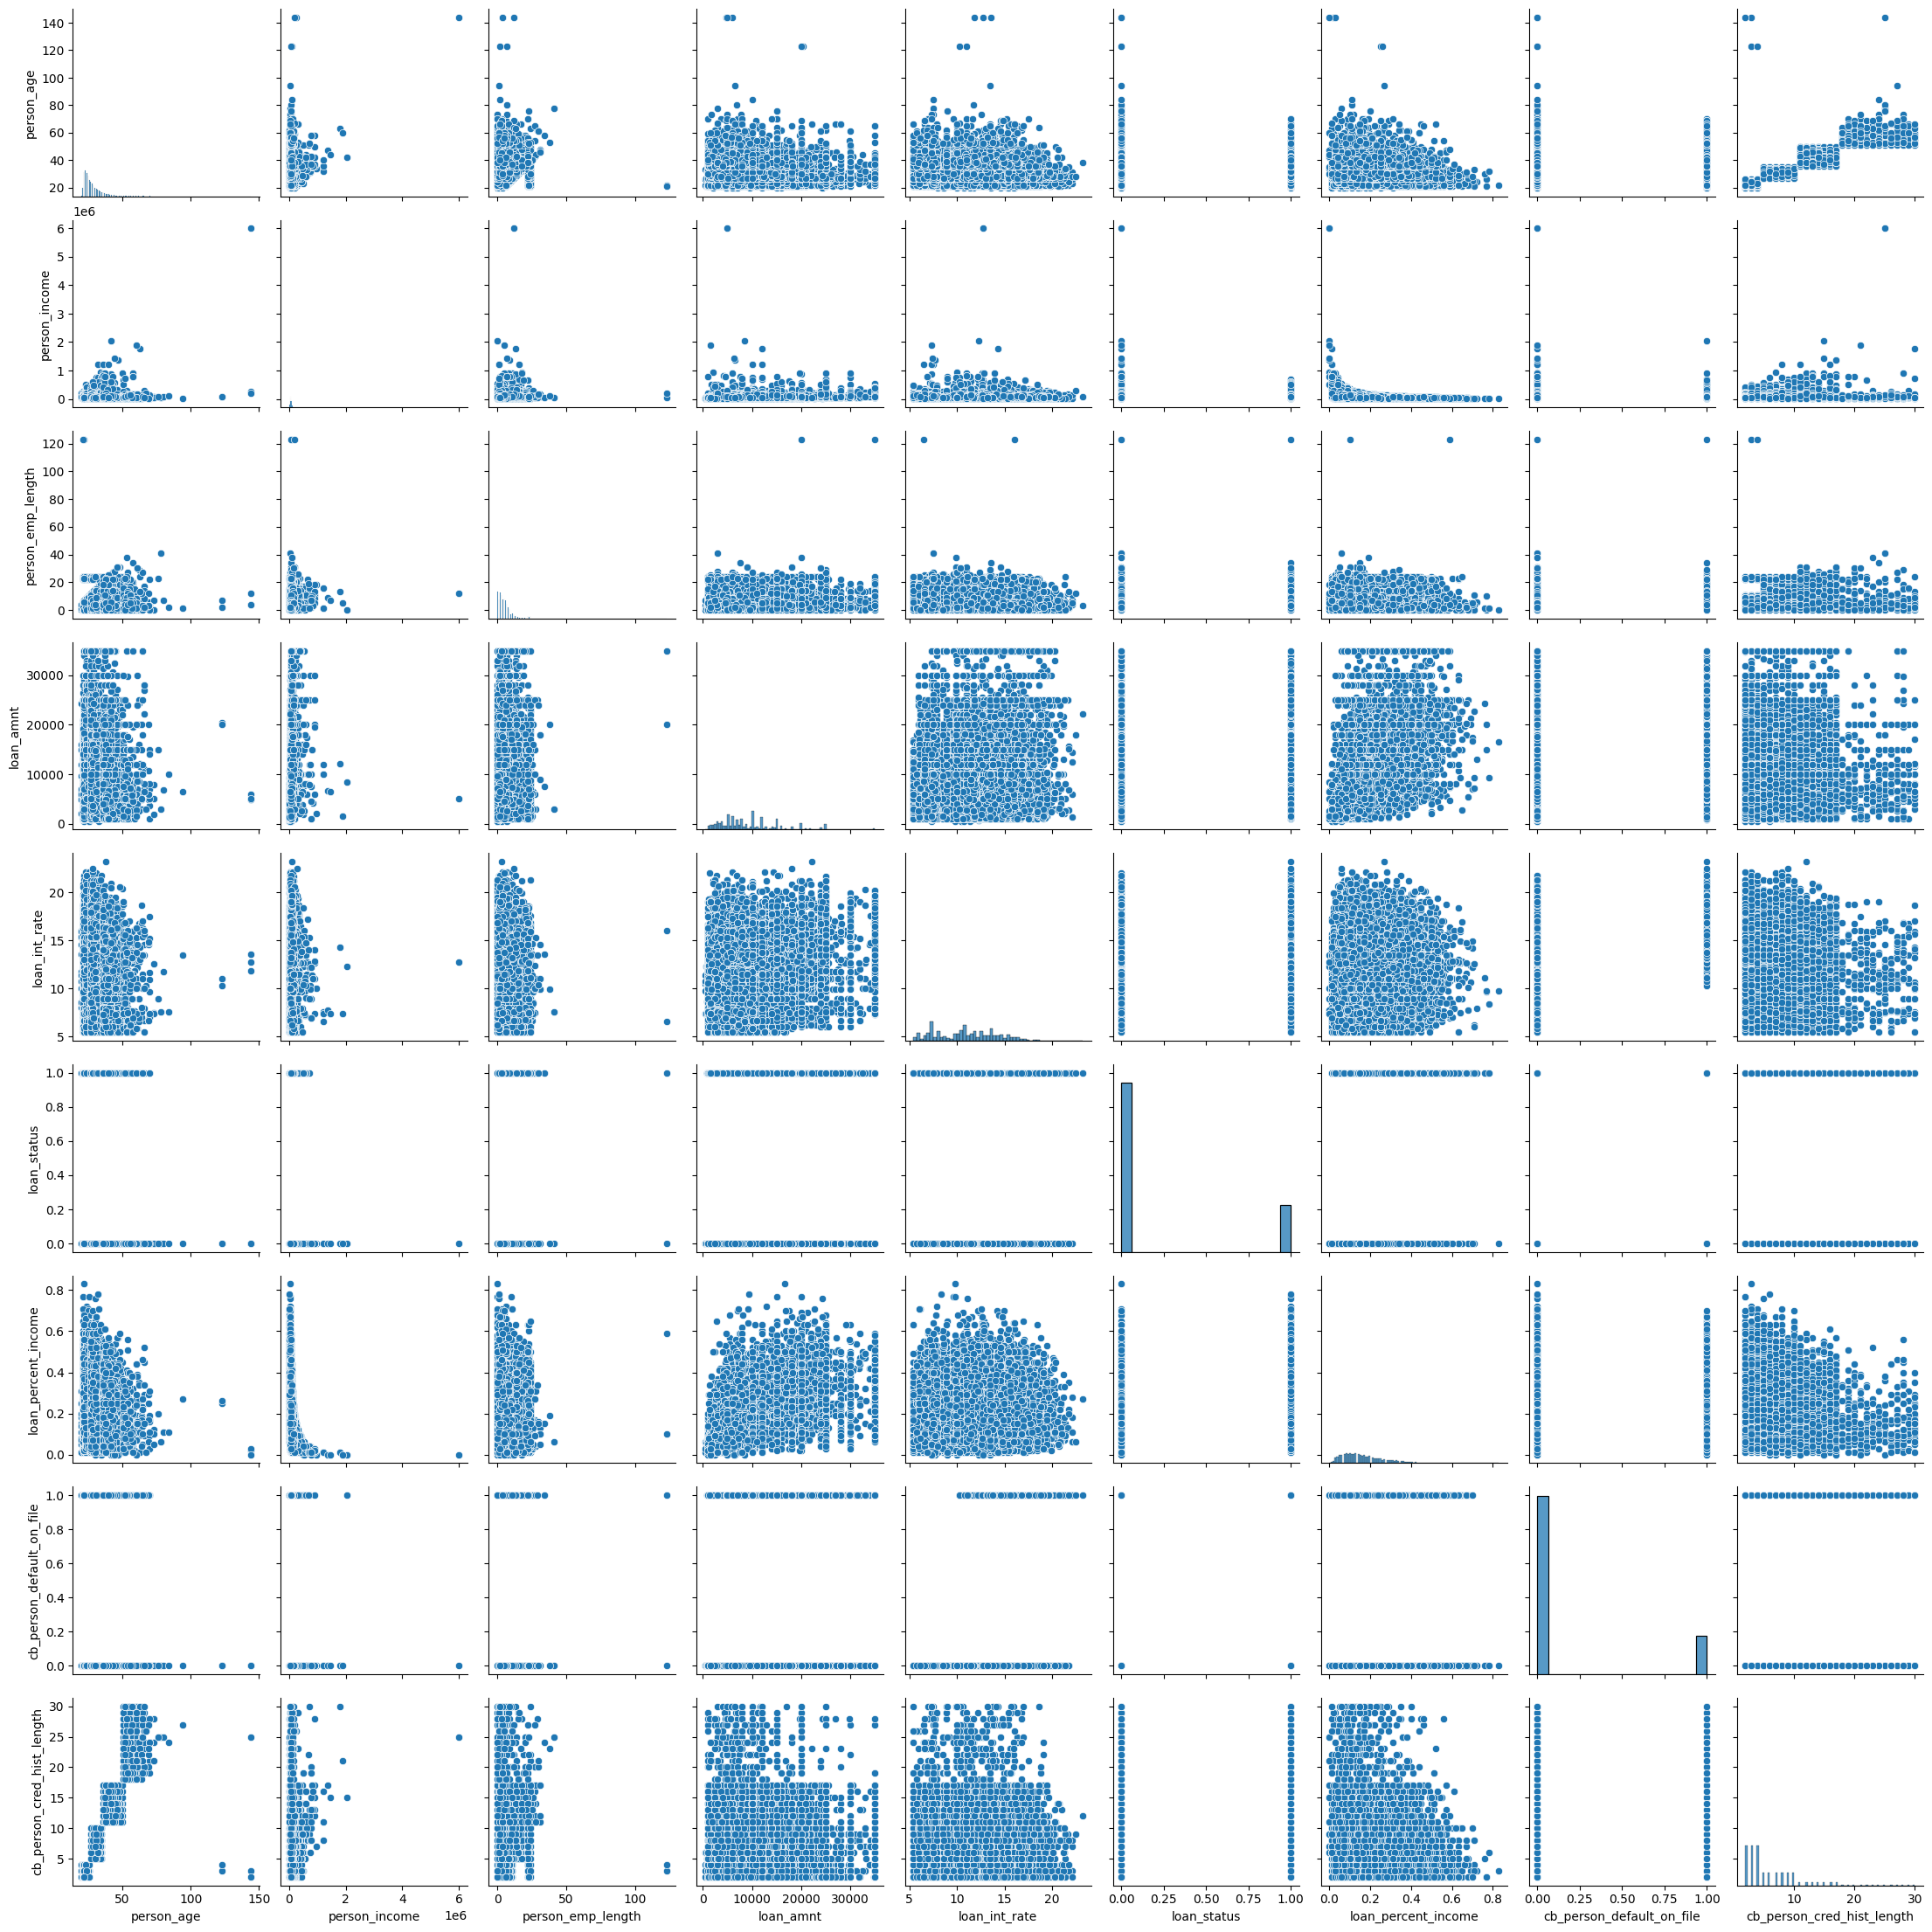

In [43]:
sns.pairplot(df)

In [44]:
df.head(2)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,1,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,0,2


<Axes: xlabel='loan_grade', ylabel='Count'>

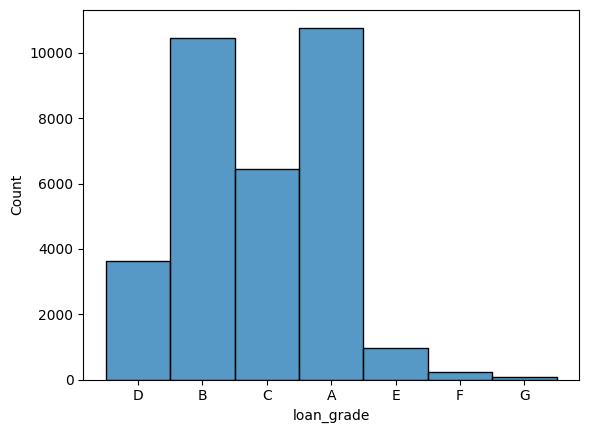

In [45]:
sns.histplot(x='loan_grade', data=df)

<Axes: xlabel='loan_grade', ylabel='Count'>

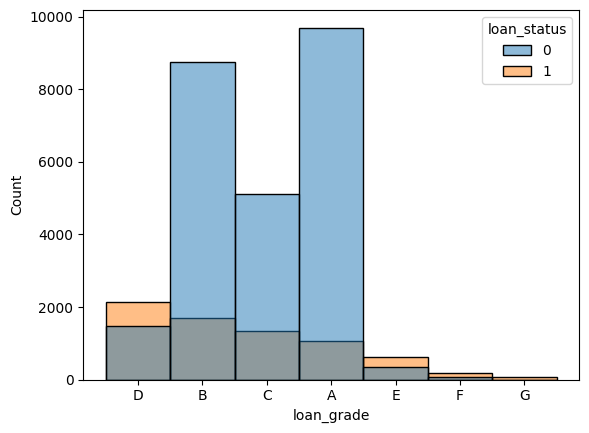

In [46]:
sns.histplot(x='loan_grade', hue='loan_status', data=df)

A,B,C are the type of Loan Grade where Default Rate is much lesser compared to other grades, so could likely be the go to category for giving loans in future or could be the first choices of offerings.

In [47]:
df.head(2)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,1,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,0,2


<Axes: xlabel='cb_person_default_on_file', ylabel='Count'>

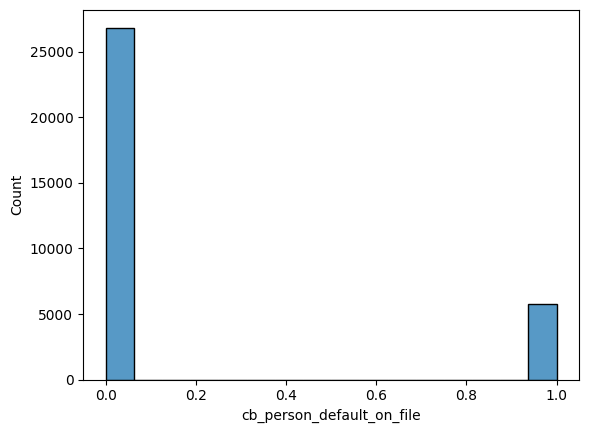

In [48]:
sns.histplot(x='cb_person_default_on_file', data=df)

<Axes: xlabel='cb_person_default_on_file', ylabel='Count'>

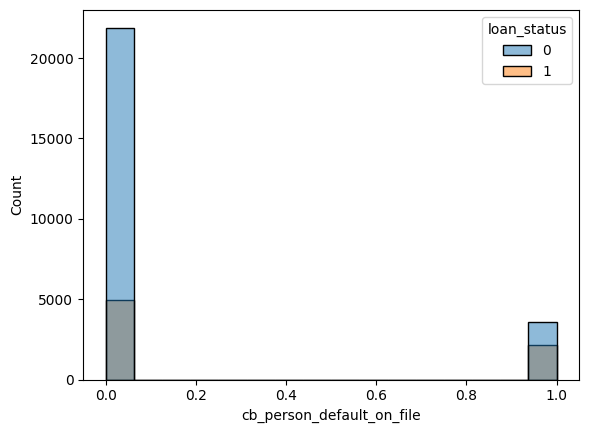

In [49]:
sns.histplot(x='cb_person_default_on_file', hue='loan_status', data=df)

Most of the Defaulters had previously defaulted.

This can be utilised by making three different buckets - low default chance bucket, Medium chance bucket and high chance bucket.
After segregating customers for each different bucket one process is made. Harder process with more checks for high default chance bucket people.

That'll do two things:
1. It will help increasing productivity for team which is doing the process by having shorter evaluation for people with good credit history.
2. It will streamline the process for good candidates leading to more customer satisfaction.

The people with no default on file tend to not make default again this time based on the data whereas the defaulters tend to default again based on the data.

<Axes: xlabel='person_age', ylabel='Count'>

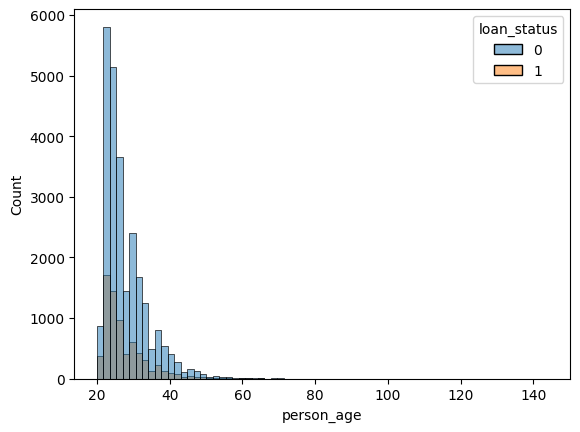

In [50]:
sns.histplot(x='person_age', hue='loan_status', data=df, bins=70)

Regardless of Age, people default at similar rates for all ages.

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'PERSONAL'),
  Text(1, 0, 'EDUCATION'),
  Text(2, 0, 'MEDICAL'),
  Text(3, 0, 'VENTURE'),
  Text(4, 0, 'HOMEIMPROVEMENT'),
  Text(5, 0, 'DEBTCONSOLIDATION')])

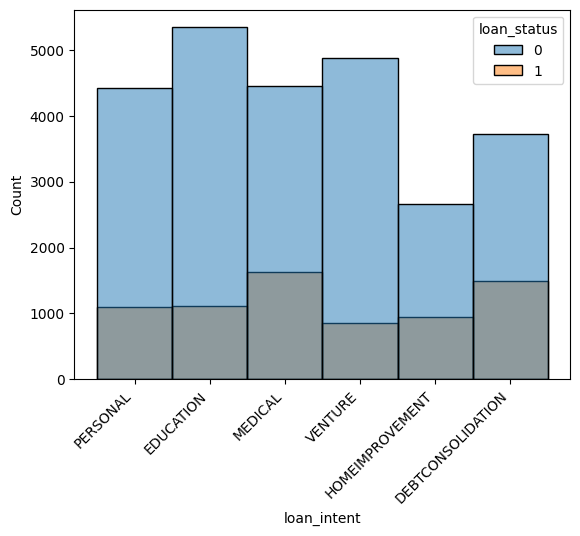

In [51]:
sns.histplot(x='loan_intent', hue='loan_status', data=df)
plt.xticks(rotation=45, ha='right')

People with Loan intent as 'Medical', 'Home Improvement', and 'Debt Consolidation' have higher rate of Defaulting compared to 'Personal', 'Education', and 'Venture'.

<Axes: xlabel='person_emp_length', ylabel='Count'>

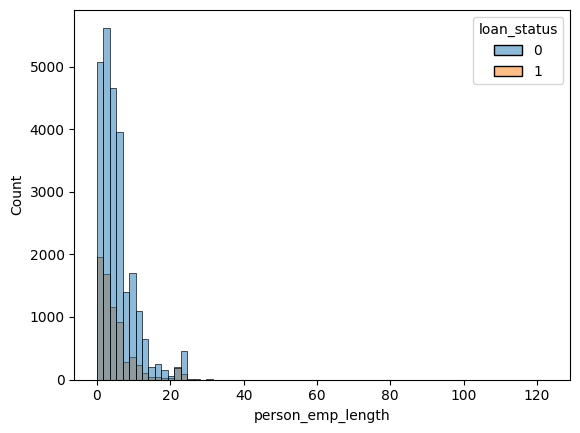

In [52]:
sns.histplot(x='person_emp_length', hue='loan_status', data=df, bins=70)

<Axes: xlabel='loan_amnt', ylabel='Count'>

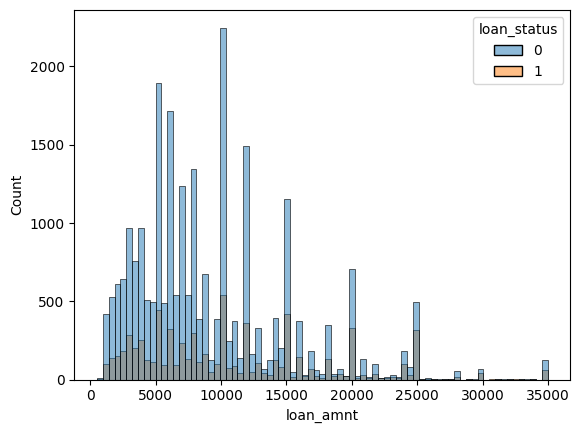

In [53]:
sns.histplot(x='loan_amnt', hue='loan_status', data=df)

In [54]:
ndf.head(1)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,loan_status,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,123.0,35000,16.02,0.59,1,1,3


In [55]:
df.head(2)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,1,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,0,2


In [56]:
grade = pd.get_dummies(df['loan_grade'], drop_first=True)

In [57]:
grade.head(2)

,B,C,D,E,F,G
0,False,False,True,False,False,False
1,True,False,False,False,False,False


In [58]:
ownership = pd.get_dummies(df['person_home_ownership'], drop_first=True)

In [59]:
ownership.head(2)

,OTHER,OWN,RENT
0,False,False,True
1,False,True,False


In [60]:
intent = pd.get_dummies(df['loan_intent'], drop_first=True)

In [61]:
intent.head(2)

,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
0,False,False,False,True,False
1,True,False,False,False,False


In [62]:
Xy = pd.concat([ndf, grade, ownership, intent], axis=1)

In [63]:
y = Xy['loan_status']

In [64]:
X = Xy.drop('loan_status', axis=1)

In [65]:
X.head(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,B,C,...,F,G,OTHER,OWN,RENT,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
0,22,59000,123.0,35000,16.02,0.59,1,3,False,False,...,False,False,False,False,True,False,False,False,True,False
1,21,9600,5.0,1000,11.14,0.10,0,2,True,False,...,False,False,False,True,False,True,False,False,False,False


In [107]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [108]:
print(X_train.shape)
print(X_test.shape)

(24435, 22)
(8146, 22)


In [68]:
from sklearn.linear_model import LogisticRegression

In [72]:
logmodel = LogisticRegression()

In [73]:
logmodel.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [74]:
pred = logmodel.predict(X_test)

In [70]:
from sklearn.metrics import classification_report, confusion_matrix

In [76]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      6349
           1       0.68      0.32      0.43      1797

    accuracy                           0.82      8146
   macro avg       0.76      0.64      0.66      8146
weighted avg       0.80      0.82      0.79      8146



Note:
1. 0 is Non Defaulter and 1 is Defaulter.
2. Recall: TP/(TP+FN)
3. Precision: TP/(TP+FP)

For Class 1:

1. In this case more False Positives is okay for Class 1 compared to False
Negatives, since more False Negatives would mean the Model is predicting falsely that the person would not default. Which could lead to providing loans to people with higher chances of defaulting.

2. Therfore metrics Recall should be high which means TP/(TP+FN).
And if Precision which is TP/(TP+FP) is low won't affect much.
But Recall for Class 1 is only 32% which is low.



For Class 0:

1. Similarily for Class 0, More False Negatives is okay compared to False Positives.
So higher Precision is desirable compared to higher recall.

2. Noting in this case Recall is 96% and Precision is 83% which is alright.


In [77]:
Xy['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


Even though Accuracy is high, it doesn't tell much about the model capabilities as dataset is highly imbalanced.
Because of which even if model predicts each item as Class 0, it would be correct most of the times.

Chatgpt suggested:

If class 1 represents something critical such as fraud, churn, or default, then:
1. 68 percent precision is acceptable.
2. 32 percent recall is dangerous.

You are missing 68 percent of real positive cases.

You would likely need:
1. Class balancing techniques
2. Adjusted decision threshold
3. SMOTE or oversampling
4. Class weights
5. Different evaluation metric such as ROC-AUC or PR-AUC

In [78]:
print(confusion_matrix(y_test, pred))

[[6079  270]
 [1224  573]]


<Axes: >

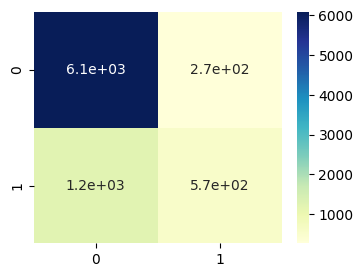

In [79]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, cmap='YlGnBu')

In [80]:
from sklearn.neighbors import KNeighborsClassifier

In [81]:
error_rate = []
for i in range(1,40):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train, y_train)
  pred_i = knn.predict(X_test)
  error_rate.append(np.mean(pred_i!=y_test))

Text(0.5, 1.0, 'Error Rate vs K Value')

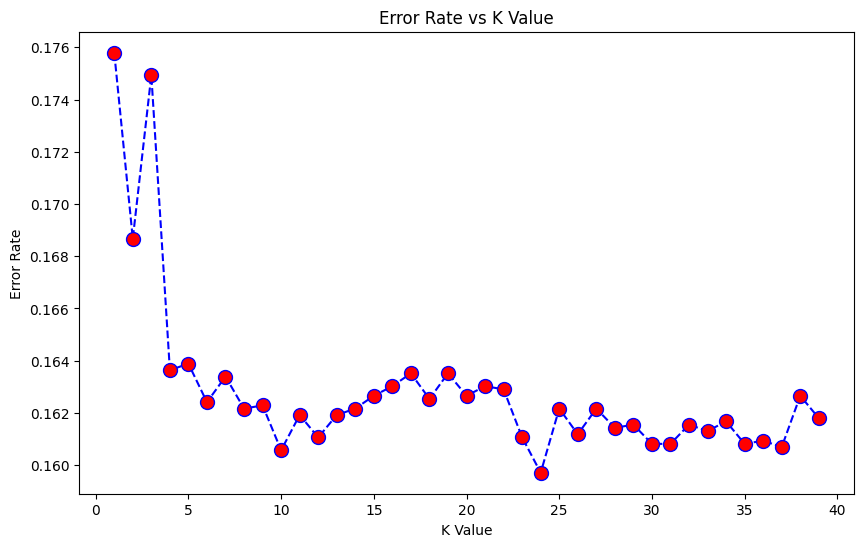

In [82]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Error Rate vs K Value')

In [83]:
knn = KNeighborsClassifier(n_neighbors=24)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [86]:
print('Confusion_Matrix:\n',confusion_matrix(y_test, pred_knn))
print('\n')
print('Classification Report:\n', classification_report(y_test, pred_knn))

Confusion_Matrix:
 [[6078  271]
 [1030  767]]


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.90      6349
           1       0.74      0.43      0.54      1797

    accuracy                           0.84      8146
   macro avg       0.80      0.69      0.72      8146
weighted avg       0.83      0.84      0.82      8146



In [87]:
y.value_counts()

,count
loan_status,
0,25473
1,7108


In [67]:
from sklearn.ensemble import RandomForestClassifier

In [90]:
error_rate_RF = []
for i in [50,100,200,500,1000,2000]:
  rf = RandomForestClassifier(n_estimators=i)
  rf.fit(X_train, y_train)
  pred_i = rf.predict(X_test)
  error_rate_RF.append(np.mean(pred_i!=y_test))

Text(0.5, 1.0, 'Error Rate for Random Forest vs K Value')

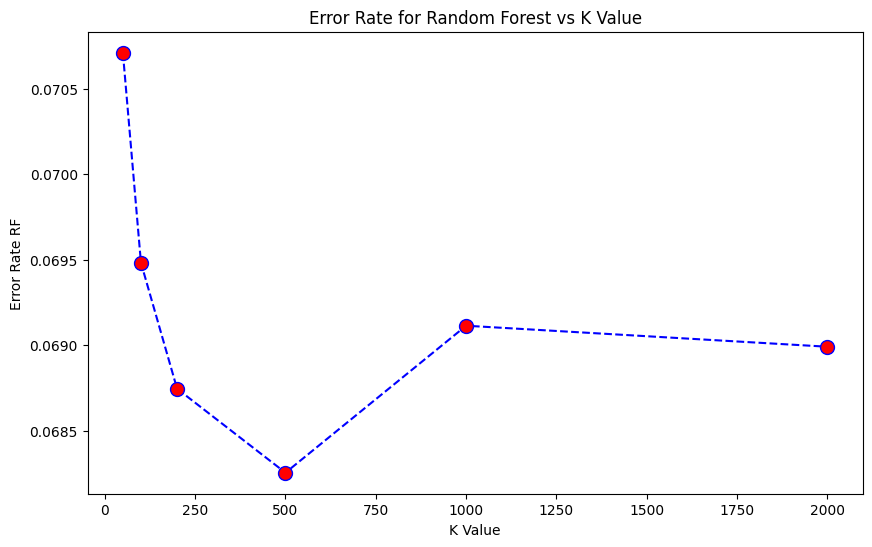

In [91]:
plt.figure(figsize=(10,6))
plt.plot([50,100,200,500,1000,2000], error_rate_RF, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.xlabel('K Value')
plt.ylabel('Error Rate RF')
plt.title('Error Rate for Random Forest vs K Value')

In [68]:
rfc = RandomForestClassifier(n_estimators=500)
rfc.fit(X_train, y_train)
pred_rfc = rfc.predict(X_test)

In [71]:
print('Confusion_Matrix:\n',confusion_matrix(y_test, pred_rfc))
print('\n')
print('Classification Report:\n', classification_report(y_test, pred_rfc))

Confusion_Matrix:
 [[6309   40]
 [ 518 1279]]


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96      6349
           1       0.97      0.71      0.82      1797

    accuracy                           0.93      8146
   macro avg       0.95      0.85      0.89      8146
weighted avg       0.93      0.93      0.93      8146



In [94]:
from sklearn.svm import SVC

In [96]:
from sklearn.model_selection import GridSearchCV

In [104]:
param_grid = {'C':[0.01,0.1,1,10], 'gamma': [0.1,0.01,0.001]}

In [105]:
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3, cv=3)

In [106]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 1/3] END .................C=0.01, gamma=0.1;, score=0.783 total time=  43.0s
[CV 2/3] END .................C=0.01, gamma=0.1;, score=0.783 total time=  42.6s
[CV 3/3] END .................C=0.01, gamma=0.1;, score=0.783 total time=  43.7s
[CV 1/3] END ................C=0.01, gamma=0.01;, score=0.783 total time=  36.1s
[CV 2/3] END ................C=0.01, gamma=0.01;, score=0.783 total time=  37.0s
[CV 3/3] END ................C=0.01, gamma=0.01;, score=0.783 total time=  35.4s
[CV 1/3] END ...............C=0.01, gamma=0.001;, score=0.783 total time=  35.3s
[CV 2/3] END ...............C=0.01, gamma=0.001;, score=0.783 total time=  33.1s
[CV 3/3] END ...............C=0.01, gamma=0.001;, score=0.783 total time=  33.6s
[CV 1/3] END ..................C=0.1, gamma=0.1;, score=0.783 total time=  52.7s
[CV 2/3] END ..................C=0.1, gamma=0.1;, score=0.783 total time=  51.9s
[CV 3/3] END ..................C=0.1, gamma=0.1;

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'gamma': [0.1, 0.01, 0.001]},
             verbose=3)

In [107]:
grid.best_params_

{'C': 10, 'gamma': 0.001}

In [108]:
grid.best_estimator_

SVC(C=10, gamma=0.001)

In [109]:
grid.best_score_

np.float64(0.8137507673419275)

In [110]:
grid_pred = grid.predict(X_test)

In [111]:
print('Confusion_Matrix:\n',confusion_matrix(y_test, grid_pred))
print('\n')
print('Classification Report:\n', classification_report(y_test, grid_pred))

Confusion_Matrix:
 [[6053  296]
 [1168  629]]


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89      6349
           1       0.68      0.35      0.46      1797

    accuracy                           0.82      8146
   macro avg       0.76      0.65      0.68      8146
weighted avg       0.80      0.82      0.80      8146



https://chatgpt.com/c/69a9d366-06e8-8324-9fc8-191f104d47f9

This link shares why might Random Forest performed better in terms of Recall for Class 1


Secondly KNN and SVM should be trained on Scaled Data since they utilise (change in distance)^2 to calculate the error. Therefore there might be some features which might be dominating and are corrupting the model by not letting the features that are important shine.

ANN

In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [170]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [171]:
X_train.shape

(24435, 22)

In [172]:
X_test.shape

(8146, 22)

In [173]:
X_train.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,B,C,...,F,G,OTHER,OWN,RENT,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
4733,24,42000,8.0,22250,11.11,0.53,0,3,True,False,...,False,False,False,False,False,False,False,False,False,False
20577,34,110000,0.0,10000,7.66,0.09,0,9,False,False,...,False,False,False,False,True,False,False,False,False,False
23411,30,108000,1.0,8000,14.96,0.07,1,7,False,False,...,False,False,False,False,True,False,False,False,True,False
2667,22,49800,1.0,3000,7.88,0.06,0,3,False,False,...,False,False,False,False,True,False,False,False,True,False
15579,23,147000,4.0,25000,10.25,0.17,0,3,True,False,...,False,False,False,False,False,False,False,False,False,False


In [174]:
X_train = X_train.astype(int)

In [175]:
X_train.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,B,C,...,F,G,OTHER,OWN,RENT,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
4733,24,42000,8,22250,11,0,0,3,1,0,...,0,0,0,0,0,0,0,0,0,0
20577,34,110000,0,10000,7,0,0,9,0,0,...,0,0,0,0,1,0,0,0,0,0
23411,30,108000,1,8000,14,0,1,7,0,0,...,0,0,0,0,1,0,0,0,1,0
2667,22,49800,1,3000,7,0,0,3,0,0,...,0,0,0,0,1,0,0,0,1,0
15579,23,147000,4,25000,10,0,0,3,1,0,...,0,0,0,0,0,0,0,0,0,0


In [176]:
X_test = X_test.astype(int)

In [177]:
y_train.head()

,loan_status
4733,0
20577,0
23411,1
2667,0
15579,0


In [178]:
from sklearn.preprocessing import StandardScaler

In [179]:
scaler = StandardScaler()

In [180]:
X_train.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'B', 'C', 'D', 'E', 'F', 'G', 'OTHER',
       'OWN', 'RENT', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL',
       'VENTURE'],
      dtype='object')

In [181]:
X_tr = X_train[['person_age','person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length']]

In [182]:
X_te = X_test[['person_age','person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length']]

In [183]:
X_tr.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,cb_person_cred_hist_length
4733,24,42000,8,22250,11,3
20577,34,110000,0,10000,7,9
23411,30,108000,1,8000,14,7
2667,22,49800,1,3000,7,3
15579,23,147000,4,25000,10,3


In [184]:
X_tr = scaler.fit_transform(X_tr)

In [185]:
X_te = scaler.transform(X_te)

In [186]:
X_tr = pd.DataFrame(X_tr)
X_te = pd.DataFrame(X_te)

In [187]:
X_tr.head()

,0,1,2,3,4,5
0,-0.588013,-0.374505,0.530713,2.004413,0.174387,-0.687826
1,0.985900,0.690479,-1.052508,0.065395,-1.056270,0.789325
2,0.356335,0.659156,-0.854605,-0.251179,1.097380,0.296941
3,-0.902795,-0.252345,-0.854605,-1.042615,-1.056270,-0.687826
4,-0.745404,1.269955,-0.260898,2.439702,-0.133277,-0.687826


In [188]:
binary_feat_tr = X_train[['cb_person_default_on_file','loan_percent_income','B', 'C','D','E','F','G','OTHER','OWN','RENT','EDUCATION','HOMEIMPROVEMENT','MEDICAL','PERSONAL','VENTURE']]

In [189]:
binary_feat_te = X_test[['cb_person_default_on_file','loan_percent_income','B', 'C','D','E','F','G','OTHER','OWN','RENT','EDUCATION','HOMEIMPROVEMENT','MEDICAL','PERSONAL','VENTURE']]

In [191]:
binary_feat_tr = binary_feat_tr.reset_index(drop=True)

In [192]:
binary_feat_te = binary_feat_te.reset_index(drop=True)

In [193]:
X_tr = pd.concat([X_tr, binary_feat_tr], axis = 1)

In [194]:
X_te = pd.concat([X_te, binary_feat_te], axis = 1)

In [195]:
X_tr.head()

,0,1,2,3,4,5,cb_person_default_on_file,loan_percent_income,B,C,...,F,G,OTHER,OWN,RENT,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
0,-0.588013,-0.374505,0.530713,2.004413,0.174387,-0.687826,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0.985900,0.690479,-1.052508,0.065395,-1.056270,0.789325,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0.356335,0.659156,-0.854605,-0.251179,1.097380,0.296941,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,-0.902795,-0.252345,-0.854605,-1.042615,-1.056270,-0.687826,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,-0.745404,1.269955,-0.260898,2.439702,-0.133277,-0.687826,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [196]:
X_tr.shape

(24435, 22)

In [197]:
X_tr = X_tr.values

In [198]:
y_tr = y_train.values

In [199]:
X_te = X_te.values

In [201]:
y_te = y_test.values

In [207]:
model = Sequential()
model.add(Dense(30, activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(30,activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(30, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [208]:
from tensorflow.keras.callbacks import EarlyStopping

In [209]:
EarlyStop = EarlyStopping(monitor = 'val_loss', verbose = 1, mode = 'min',patience = 30)

In [210]:
model.fit(X_tr, y_tr, epochs = 300, validation_data=(X_te, y_te), verbose = 1, callbacks = [EarlyStop])

Epoch 1/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.5137 - val_loss: 0.3597
Epoch 2/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3888 - val_loss: 0.3309
Epoch 3/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3592 - val_loss: 0.3129
Epoch 4/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3413 - val_loss: 0.2987
Epoch 5/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3225 - val_loss: 0.2913
Epoch 6/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3106 - val_loss: 0.2848
Epoch 7/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3025 - val_loss: 0.2800
Epoch 8/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2909 - val_loss: 0.2742
Epoch 9/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2844 - val_loss: 0.2640
Epoch 10/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2751 - val_loss: 0.2642
Epoch 11/300
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2697 - val_loss: 0.2602
Epoch 12/300
764/764 ━━━━━━━━━━━━━━━━━━━━

In [211]:
model_losses = pd.DataFrame(model.history.history)

<Axes: >

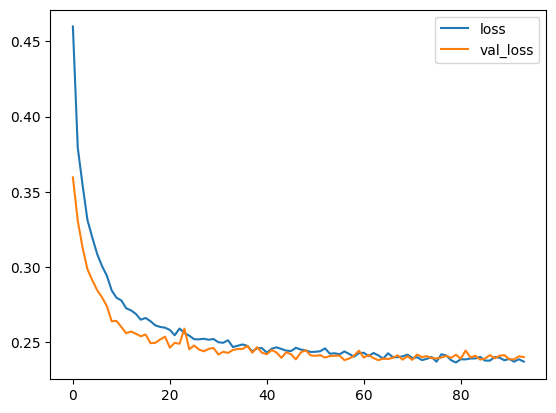

In [212]:
model_losses.plot()

In [213]:
preds_ann = model.predict(X_te)

255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [215]:
preds_ann[0]

array([0.14565939], dtype=float32)

Converting probabilities to 1 and 0

In [217]:
predictions_ann_binary = [1 if p>0.5  else 0 for p in preds_ann]

In [223]:
preds_ann_df = pd.DataFrame(predictions_ann_binary, columns = ['loan_Status'])

In [225]:
preds_ann_df.value_counts()

,count
loan_Status,
0,6887
1,1259


In [220]:
from sklearn.metrics import confusion_matrix, classification_report

In [221]:
print('Confusion_Matrix:\n',confusion_matrix(y_te, predictions_ann_binary))
print('\n')
print('Classification Report:\n', classification_report(y_te, predictions_ann_binary))

Confusion_Matrix:
 [[6288   61]
 [ 599 1198]]


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95      6349
           1       0.95      0.67      0.78      1797

    accuracy                           0.92      8146
   macro avg       0.93      0.83      0.87      8146
weighted avg       0.92      0.92      0.91      8146

